In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers,applications
import matplotlib.pyplot as plt

2025-11-14 16:49:18.918759: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

BATCH_SIZE = 16
IMAGE_SIZE = 190
CHANNELS=3
EPOCHS=50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Diseases",
    shuffle=True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)


Found 3596 files belonging to 3 classes.


I0000 00:00:1763138966.883638    6719 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
class_names =dataset.class_names
class_names

['benign', 'melanoma', 'non_melanoma_cancer']

In [5]:

for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(16, 190, 190, 3)
[0 2 0 1 1 2 0 2 2 1 0 0 0 1 0 1]


2025-11-14 16:49:28.487793: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
len(dataset)

225

In [7]:
225*16


3600

2025-11-14 16:49:28.710826: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


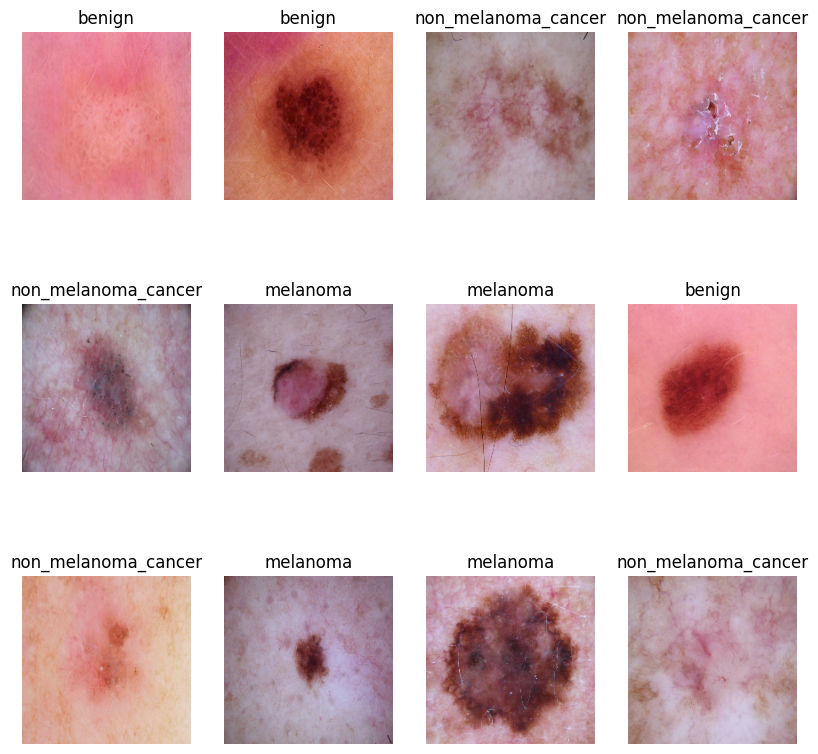

In [8]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12): 
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")
    

In [9]:
len(dataset)

225

In [10]:
train_size = 0.7
len(dataset)*train_size

157.5

In [11]:
train_ds = dataset.take(157)
len(train_ds)

157

In [12]:
test_ds = dataset.skip(157)
len(test_ds)

68

In [13]:
val_size=0.15
len(dataset)*val_size

33.75

In [14]:
val_ds = test_ds.take(33)
len(val_ds)

33

In [15]:
test_ds = test_ds.skip(33)
len(test_ds)

35

In [16]:
def get_dataset_partitions_tf(ds,train_split=0.7,val_split=0.15,test_split=0.1,shuffle=True , shuffle_size = 10000):
        ds_size  = len(ds)
        if shuffle:
            ds = ds.shuffle(shuffle_size, seed=12)
            
        train_size = int(train_split *ds_size)
        val_size = int(val_split * ds_size)
    
        train_ds = ds.take(train_size)
    
        val_ds=ds.skip(train_size).take(val_size)
        test_ds = ds.skip(train_size).skip(val_size)
    
        return train_ds,val_ds,test_ds

In [17]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [18]:
len(train_ds)

157

In [19]:
len(val_ds)

33

In [20]:
len(test_ds)

35

In [21]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds= test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [22]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255)
])



In [23]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

In [24]:


# --- Build base ---
base_model = applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),
    include_top=False,
    weights='imagenet'
)

# --- Build top model ---
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

# --- Run one forward pass to build model ---
dummy_input = tf.random.normal([1, IMAGE_SIZE, IMAGE_SIZE, 3])
_ = model(dummy_input)

# --- Freeze base ---
base_model.trainable = False

# --- Compile ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- Verify ---
model.summary()


/tmp/ipykernel_6719/938508166.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(
2025-11-14 16:49:33.097583: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 190, 190, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (1, 190, 190, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 6, 6, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 1280)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 3)                 │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
# Unfreeze last N layers
N = 20   # tune this
base_model.trainable = True
for layer in base_model.layers[:-N]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 190, 190, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (1, 190, 190, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 6, 6, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 1280)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 3)                 │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,209,923 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [49]:
# --- Callbacks ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
]

# --- Training (no class weights needed) ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.6061 - loss: 0.8883 - val_accuracy: 0.6761 - val_loss: 0.7515 - learning_rate: 1.0000e-05
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.6427 - loss: 0.8100 - val_accuracy: 0.6913 - val_loss: 0.7414 - learning_rate: 1.0000e-05
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.6555 - loss: 0.7762 - val_accuracy: 0.6989 - val_loss: 0.7249 - learning_rate: 1.0000e-05
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.6782 - loss: 0.7361 - val_accuracy: 0.7027 - val_loss: 0.6986 - learning_rate: 1.0000e-05
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.6782 - loss: 0.7115 - val_accuracy: 0.7197 - val_loss: 0.6813 - learning_rate: 1.0000e-05
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.6978 - loss: 0.6944 - val_accuracy: 0.7159 - val_loss: 0.6670 - learning_rate: 1.0000e-05
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/ste

In [50]:
scores= model.evaluate(test_ds)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7750 - loss: 0.5334


In [51]:
scores


[0.5333583950996399, 0.7749999761581421]

In [52]:
history


In [53]:
history.params


{'verbose': 'auto', 'epochs': 50, 'steps': 157}

In [54]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [55]:
history.history['accuracy']

[0.6060606241226196,
 0.6427432298660278,
 0.6555023789405823,
 0.6782296895980835,
 0.6782296895980835,
 0.6977671384811401,
 0.6953747868537903,
 0.7185007929801941,
 0.7005581855773926,
 0.7224880456924438,
 0.729266345500946,
 0.7324561476707458,
 0.7496013045310974,
 0.7472089529037476,
 0.7312599420547485,
 0.7472089529037476,
 0.7460127472877502,
 0.7519935965538025,
 0.7619616985321045,
 0.7615630030632019,
 0.7671451568603516,
 0.7771132588386536,
 0.7775119543075562,
 0.7870813608169556,
 0.7838915586471558,
 0.7882775068283081,
 0.7938596606254578,
 0.7946571111679077,
 0.7846890091896057,
 0.790669858455658,
 0.7978469133377075,
 0.8018341064453125,
 0.8046252131462097,
 0.8058213591575623,
 0.8026315569877625,
 0.8070175647735596,
 0.8221690654754639,
 0.8225677609443665,
 0.8281499147415161,
 0.8133971095085144,
 0.8293461203575134,
 0.8269537687301636,
 0.8245614171028137,
 0.8345295190811157,
 0.8249601125717163,
 0.8249601125717163,
 0.8261563181877136]

In [56]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

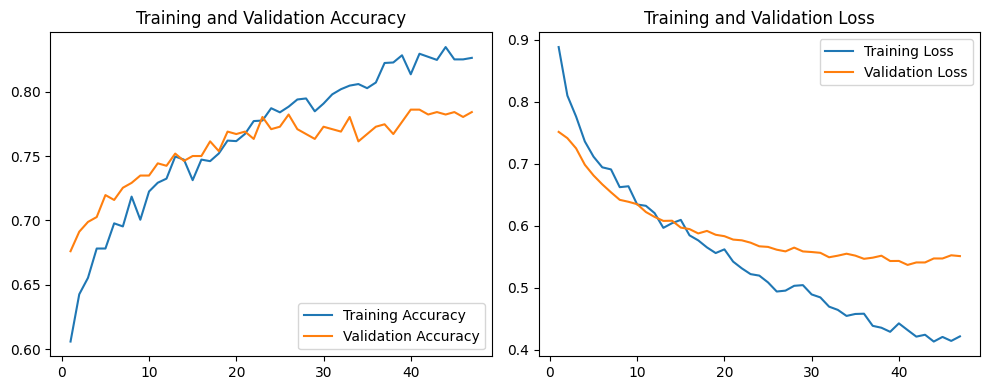

In [57]:
epochs_ran = len(acc)  # number of completed epochs

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(range(1, epochs_ran + 1), acc, label='Training Accuracy')
plt.plot(range(1, epochs_ran + 1), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(1, epochs_ran + 1), loss, label='Training Loss')
plt.plot(range(1, epochs_ran + 1), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

first image to predict
actual label: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
predicted label: benign


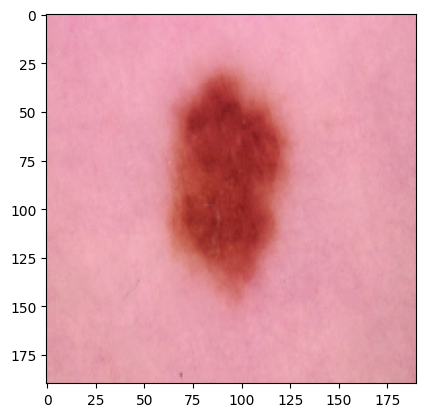

In [87]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [88]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


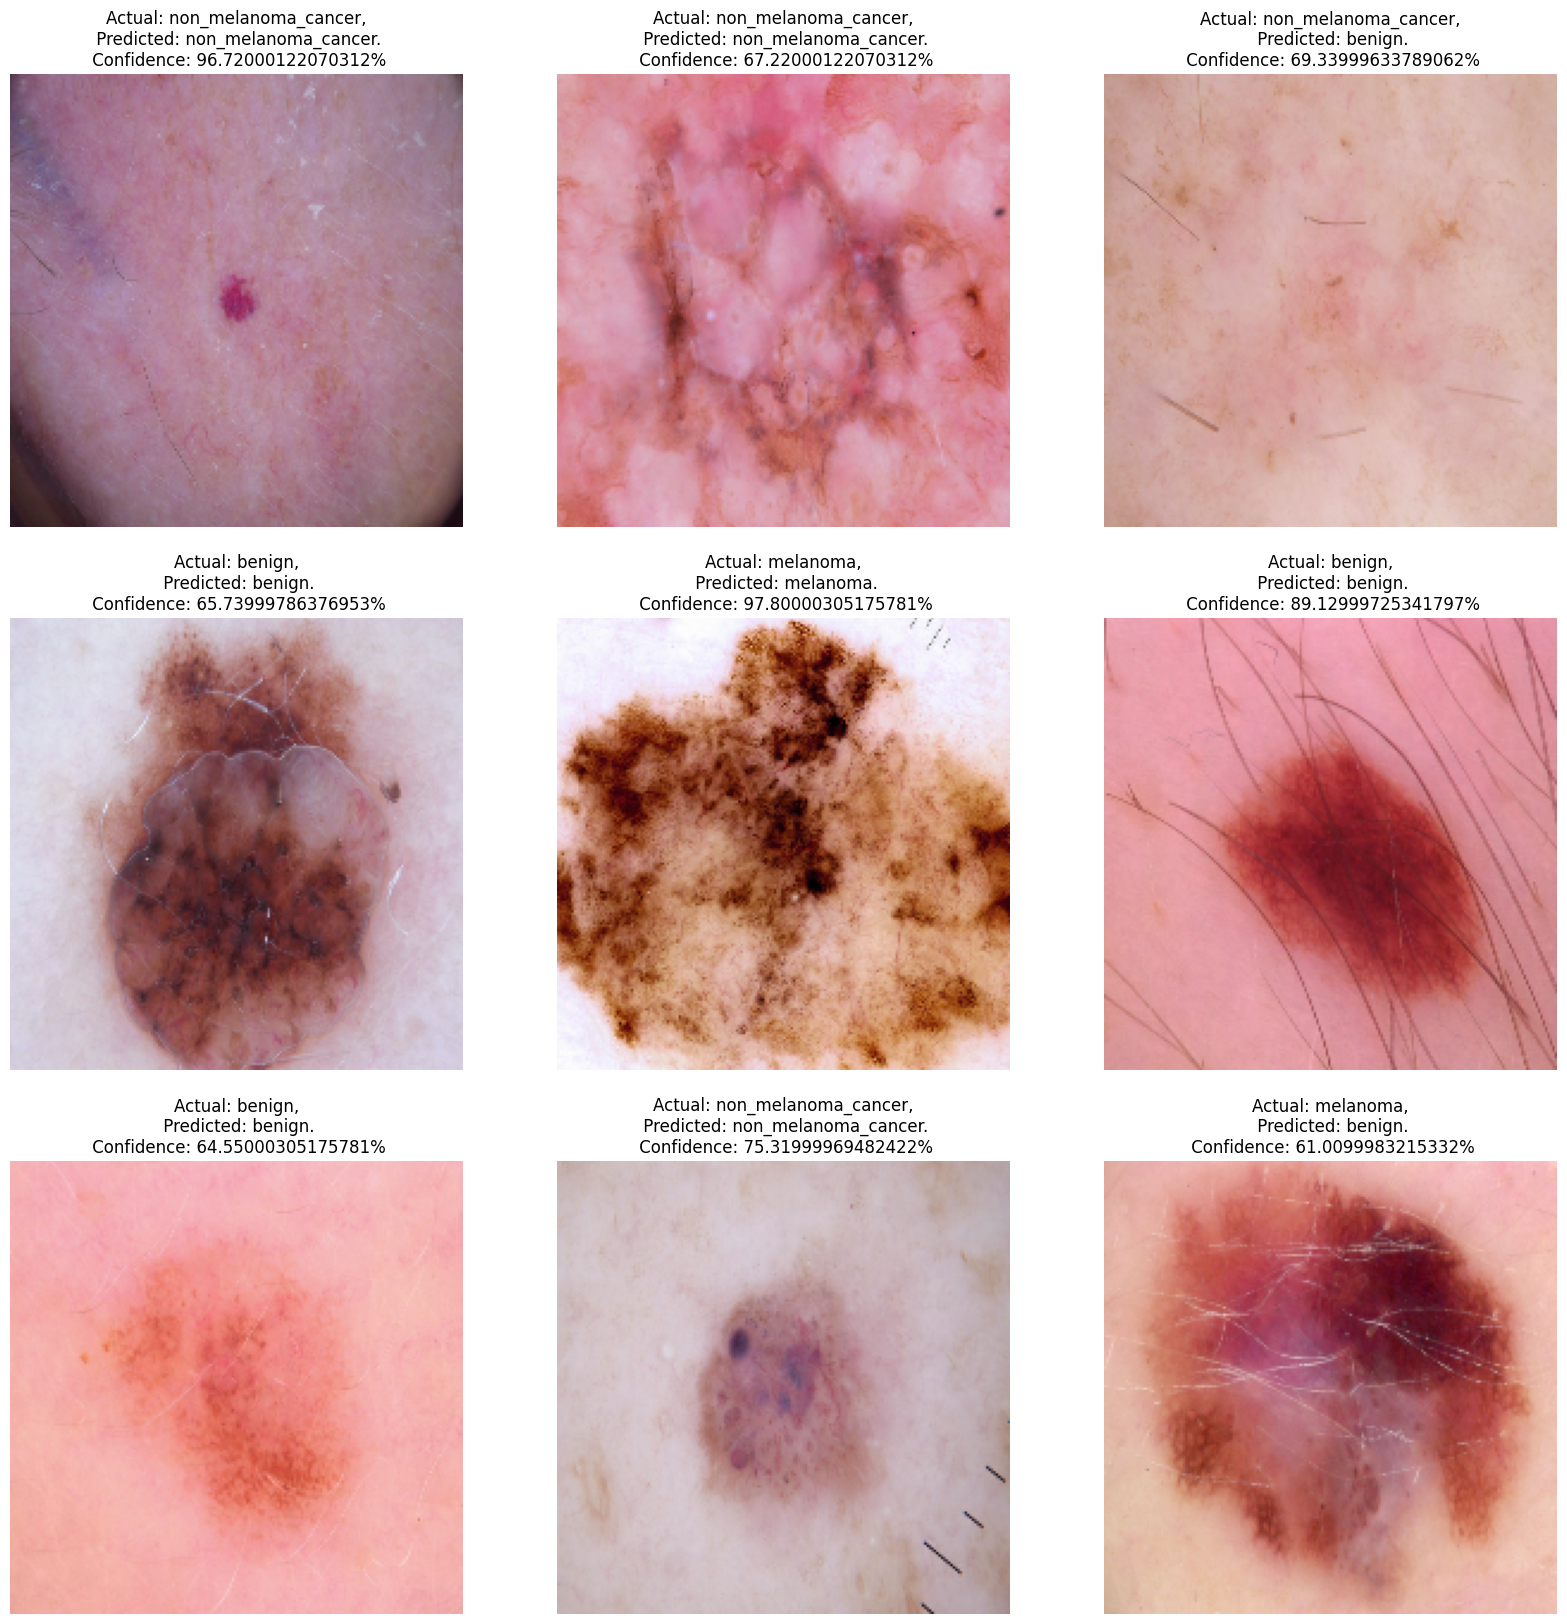

In [90]:

plt.figure(figsize=(20, 20))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [96]:
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Re-compile with very small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.8242 - loss: 0.4314 - val_accuracy: 0.7765 - val_loss: 0.5563
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.8317 - loss: 0.4209 - val_accuracy: 0.7727 - val_loss: 0.5561
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8250 - loss: 0.4271 - val_accuracy: 0.7708 - val_loss: 0.5624
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8301 - loss: 0.4077 - val_accuracy: 0.7633 - val_loss: 0.5672
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8250 - loss: 0.4150 - val_accuracy: 0.7652 - val_loss: 0.5805
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8285 - loss: 0.4054 - val_accuracy: 0.7670 - val_loss: 0.5756
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8389 - loss: 0.3937 - val_accuracy: 0.7708 - val_loss: 0.5638
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8393 - loss: 0.3982 - va